<a href="https://colab.research.google.com/github/bakhtawermajeed-wq/SIR-Parameter-Estimation-Evolutionary-Methods/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

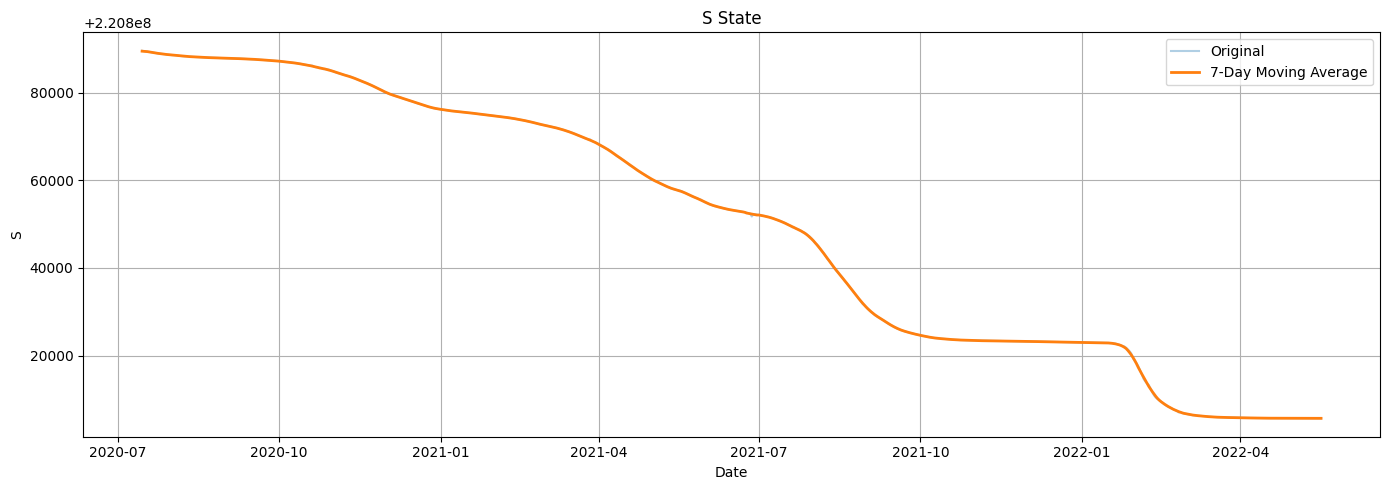

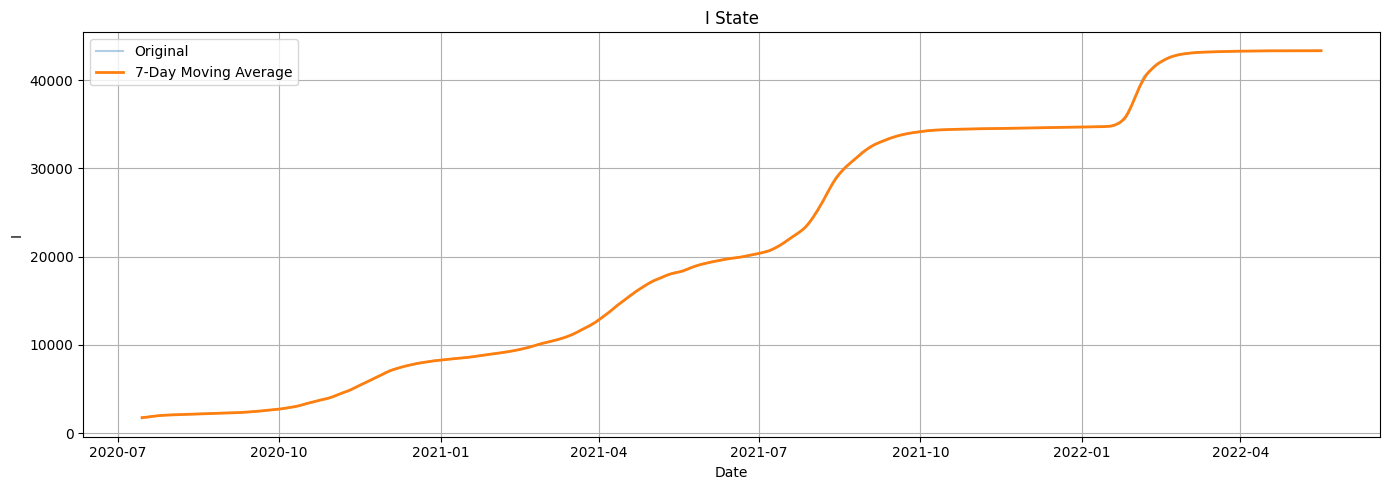

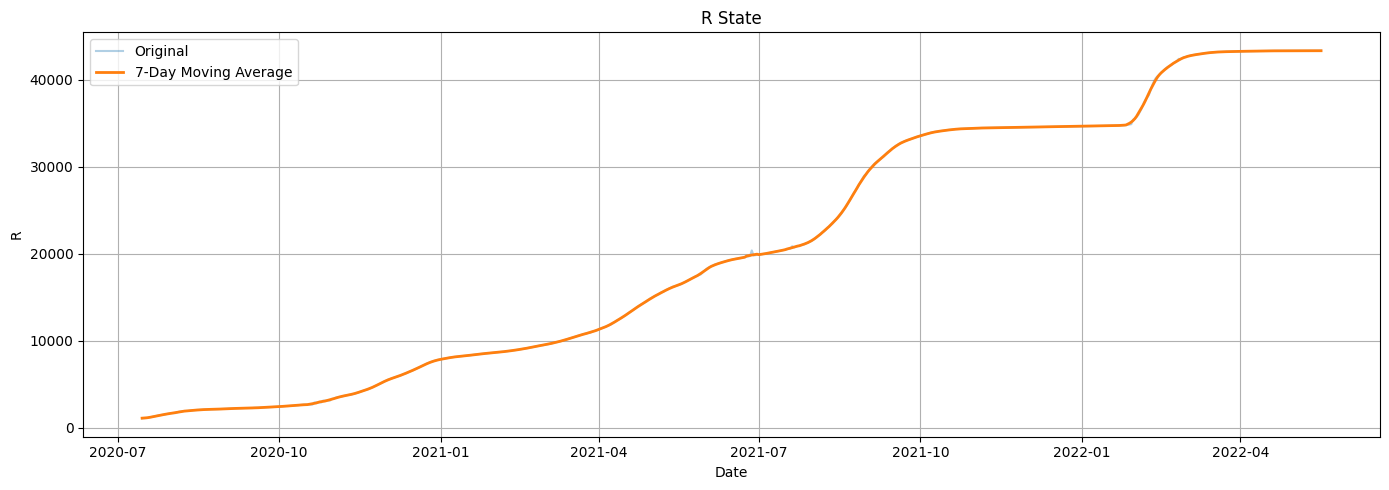

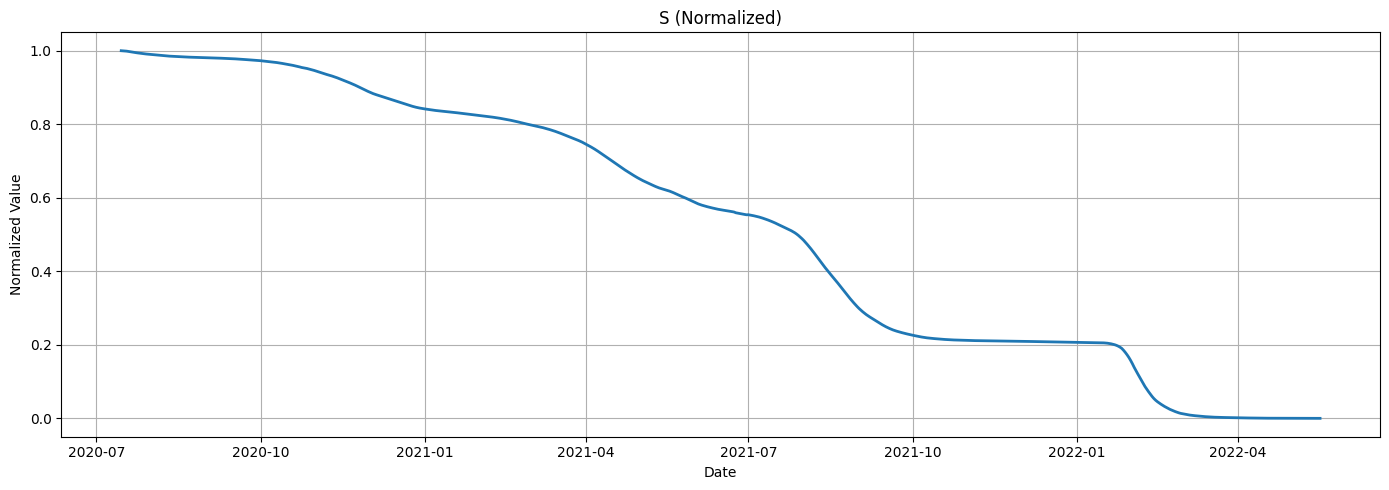

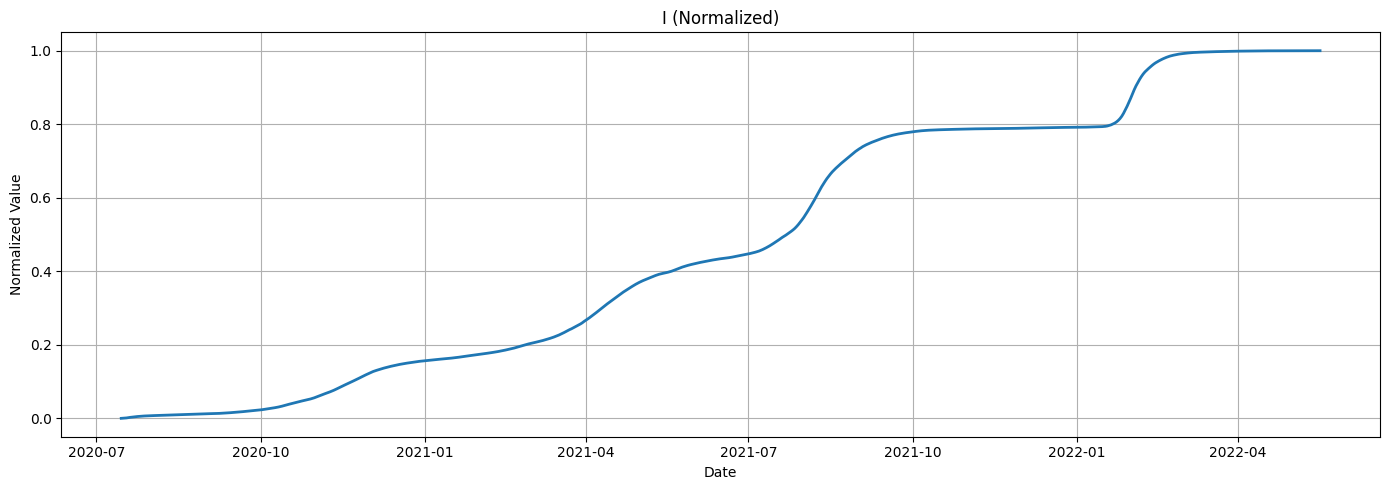

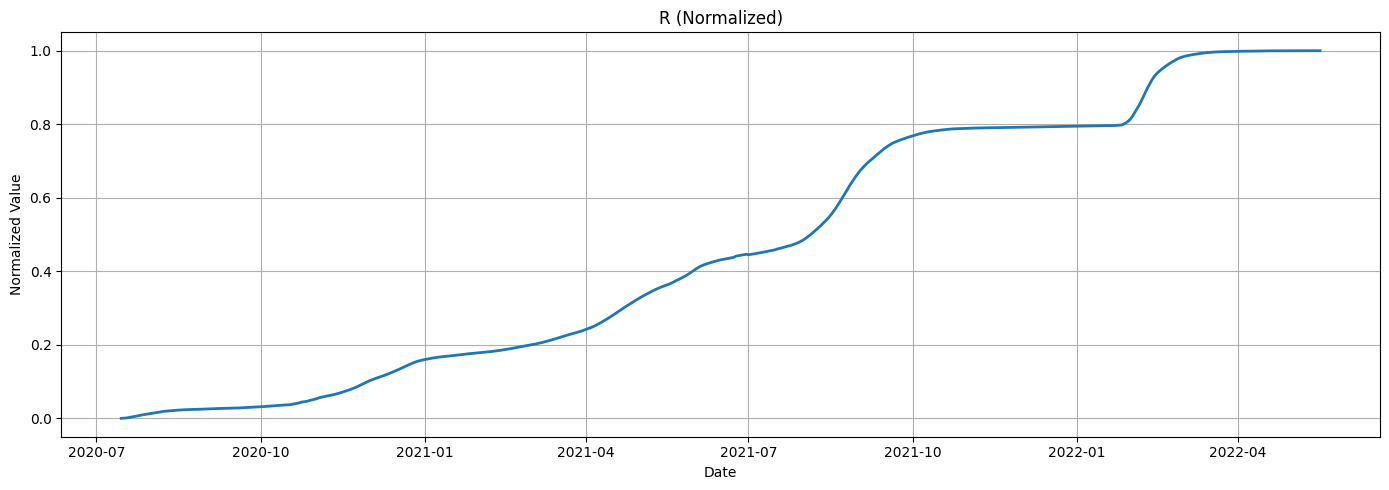

Finished Successfully!
            Recovered  Deaths   Active  AJK\nTotal \nInfected  \
Date                                                            
2020-07-15    1049.00   46.00  1688.00                 593.00   
2020-07-16    1061.00   46.00  1771.00                 664.00   
2020-07-17    1077.00   46.00  1808.00                 685.00   
2020-07-18    1094.00   46.00  1840.00                 700.00   
2020-07-19    1139.25   46.25  1864.25                 678.75   

            Balochistan\nRecovered  Balochistan\nDeaths  \
Date                                                      
2020-07-15                  7883.0                 46.0   
2020-07-16                  8002.0                127.0   
2020-07-17                  8161.0                128.0   
2020-07-18                  8313.0                131.0   
2020-07-19                  8580.0                132.0   

            Balochistan\nTotal \nPositive  Balochistan Total \nInfected  \
Date                            

In [4]:
# ===========================================================
# MODEL-CONSTRAINED COMPRESSIVE SENSING
# STEP 1: Import Libraries
# ===========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ===========================================================
# STEP 2: Load Dataset
# ===========================================================

file_path = "/content/COVID_data.xlsx"

df = pd.read_excel(file_path)

# ===========================================================
# STEP 3: Rename Columns (Modify if Needed)
# ===========================================================

df = df.rename(columns={
    "Date":"Date",
    "AJK Total \nPositive":"Active",
    "AJK\nRecovered":"Recovered",
    "AJK\nDeaths":"Deaths"
})

# ===========================================================
# STEP 4: Convert Date
# ===========================================================

df["Date"] = pd.to_datetime(df["Date"])

# ===========================================================
# STEP 5: Remove Duplicate Dates
# ===========================================================

df = df.drop_duplicates(subset="Date")

# ===========================================================
# STEP 6: Sort by Date
# ===========================================================

df = df.sort_values("Date")

# ===========================================================
# STEP 7: Create Continuous Daily Timeline
# ===========================================================

full_dates = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

df = (
    df.set_index("Date")
      .reindex(full_dates)
)

df.index.name = "Date"

# ===========================================================
# STEP 8: Interpolate Missing Values
# ===========================================================

df = df.interpolate(method='linear')

# ===========================================================
# STEP 9: Define Total Population
# ===========================================================

# Pakistan population
# Replace if using another year

N = 220892340

# ===========================================================
# STEP 10: Construct SIR States
# ===========================================================

# Infected

df["I"] = df["Active"]

# Removed
# (Recovered + Deaths)

df["R"] = df["Recovered"] + df["Deaths"]

# Susceptible

df["S"] = N - df["I"] - df["R"]

# Prevent negative values
df["S"] = df["S"].clip(lower=0)

# ===========================================================
# STEP 11: Apply 7-Day Moving Average
# ===========================================================

sir_columns = ["S","I","R"]

for col in sir_columns:

    df[col+"_MA7"] = (
        df[col]
        .rolling(
            window=7,
            center=True,
            min_periods=1
        )
        .mean()
    )

# ===========================================================
# STEP 12: Normalize Between 0 and 1
# ===========================================================

scaler = MinMaxScaler()

for col in sir_columns:

    df[col+"_Norm"] = scaler.fit_transform(
        df[[col+"_MA7"]]
    )

# ===========================================================
# STEP 13: Plot Original vs Smoothed
# ===========================================================

for col in sir_columns:

    plt.figure(figsize=(14,5))

    plt.plot(
        df.index,
        df[col],
        alpha=0.35,
        label="Original"
    )

    plt.plot(
        df.index,
        df[col+"_MA7"],
        linewidth=2,
        label="7-Day Moving Average"
    )

    plt.title(col + " State")

    plt.xlabel("Date")

    plt.ylabel(col)

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

# ===========================================================
# STEP 14: Plot Normalized States
# ===========================================================

for col in sir_columns:

    plt.figure(figsize=(14,5))

    plt.plot(
        df.index,
        df[col+"_Norm"],
        linewidth=2
    )

    plt.title(col + " (Normalized)")

    plt.xlabel("Date")

    plt.ylabel("Normalized Value")

    plt.grid(True)

    plt.tight_layout()

    plt.show()

# ===========================================================
# STEP 15: Save Dataset
# ===========================================================

df.to_excel(
    "Pakistan_COVID19_SIR_Preprocessed.xlsx"
)

print("Finished Successfully!")

print(df.head())